In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
forecast = pd.read_csv("../Data/hybrid_forecast.csv")

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,...,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat,LSTM,HybridForecast
0,2011-12-10 12:50:00,268.519147,-129.027954,544.857984,268.519147,268.519147,-52.753661,-52.753661,-52.753661,-38.597378,...,-38.597378,-14.156283,-14.156283,-14.156283,0.0,0.0,0.0,215.765486,255.025906,235.395696
1,2011-12-11 12:50:00,268.525519,-66.012861,602.487254,268.525519,268.525519,-18.924490,-18.924490,-18.924490,-3.796953,...,-3.796953,-15.127537,-15.127537,-15.127537,0.0,0.0,0.0,249.601028,255.283878,252.442453
2,2011-12-12 12:50:00,268.531890,-69.102760,588.240325,268.531890,268.531890,5.666633,5.666633,5.666633,21.656584,...,21.656584,-15.989951,-15.989951,-15.989951,0.0,0.0,0.0,274.198523,255.428889,264.813706
3,2011-12-13 12:50:00,268.538262,-91.831727,572.280720,268.538262,268.538262,-8.106154,-8.106154,-8.106154,8.625425,...,8.625425,-16.731579,-16.731579,-16.731579,0.0,0.0,0.0,260.432108,255.538403,257.985256
4,2011-12-14 12:50:00,268.544634,-71.458632,606.491114,268.544634,268.544634,-12.441212,-12.441212,-12.441212,4.899171,...,4.899171,-17.340383,-17.340383,-17.340383,0.0,0.0,0.0,256.103422,255.617276,255.860349


In [3]:
inventory = pd.DataFrame({

    "StockCode":[
        "85123A",
        "71053",
        "84406B",
        "84029G",
        "22752"
    ],

    "CurrentStock":[
        30,
        80,
        45,
        20,
        100
    ]

})

inventory

,StockCode,CurrentStock
0,85123A,30
1,71053,80
2,84406B,45
3,84029G,20
4,22752,100


In [4]:
inventory["PredictedDemand"] = [

    70,

    60,

    55,

    40,

    120

]

In [5]:
inventory["ReorderQuantity"] = (

    inventory["PredictedDemand"]

    -

    inventory["CurrentStock"]

)

inventory["ReorderQuantity"] = inventory["ReorderQuantity"].clip(lower=0)

In [6]:
def inventory_status(row):

    if row["CurrentStock"] == 0:

        return "Out of Stock"

    elif row["CurrentStock"] < row["PredictedDemand"]:

        return "Reorder Required"

    else:

        return "Sufficient Stock"

inventory["Status"] = inventory.apply(

    inventory_status,

    axis=1
)

In [7]:
inventory["SafetyStock"] = (

    inventory["PredictedDemand"] * 0.20

).round()

In [8]:
inventory["RecommendedOrder"] = (

    inventory["PredictedDemand"]

    +

    inventory["SafetyStock"]

    -

    inventory["CurrentStock"]

)

inventory["RecommendedOrder"] = (

    inventory["RecommendedOrder"]

    .clip(lower=0)

    .astype(int)

)

In [9]:
inventory[
[
    "StockCode",

    "CurrentStock",

    "PredictedDemand",

    "SafetyStock",

    "RecommendedOrder",

    "Status"
]]

,StockCode,CurrentStock,PredictedDemand,SafetyStock,RecommendedOrder,Status
0,85123A,30,70,14.0,54,Reorder Required
1,71053,80,60,12.0,0,Sufficient Stock
2,84406B,45,55,11.0,21,Reorder Required
3,84029G,20,40,8.0,28,Reorder Required
4,22752,100,120,24.0,44,Reorder Required


In [10]:
for _, row in inventory.iterrows():

    print("=" * 60)

    print("Product :", row["StockCode"])

    print("Current Stock :", row["CurrentStock"])

    print("Predicted Demand :", row["PredictedDemand"])

    print("Safety Stock :", row["SafetyStock"])

    print("Recommended Order :", row["RecommendedOrder"])

    print("Status :", row["Status"])

Product : 85123A
Current Stock : 30
Predicted Demand : 70
Safety Stock : 14.0
Recommended Order : 54
Status : Reorder Required
Product : 71053
Current Stock : 80
Predicted Demand : 60
Safety Stock : 12.0
Recommended Order : 0
Status : Sufficient Stock
Product : 84406B
Current Stock : 45
Predicted Demand : 55
Safety Stock : 11.0
Recommended Order : 21
Status : Reorder Required
Product : 84029G
Current Stock : 20
Predicted Demand : 40
Safety Stock : 8.0
Recommended Order : 28
Status : Reorder Required
Product : 22752
Current Stock : 100
Predicted Demand : 120
Safety Stock : 24.0
Recommended Order : 44
Status : Reorder Required


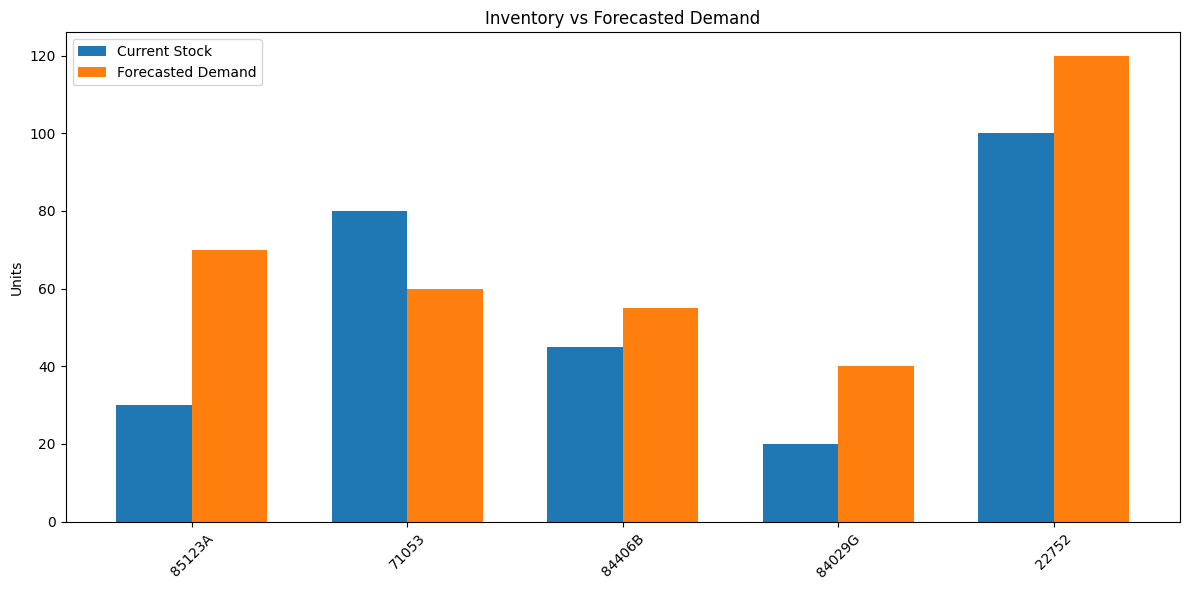

In [11]:
plt.figure(figsize=(12,6))

x = np.arange(len(inventory))

width = 0.35

plt.bar(

    x - width/2,

    inventory["CurrentStock"],

    width,

    label="Current Stock"

)

plt.bar(

    x + width/2,

    inventory["PredictedDemand"],

    width,

    label="Forecasted Demand"

)

plt.xticks(

    x,

    inventory["StockCode"],

    rotation=45

)

plt.ylabel("Units")

plt.title("Inventory vs Forecasted Demand")

plt.legend()

plt.tight_layout()

plt.show()

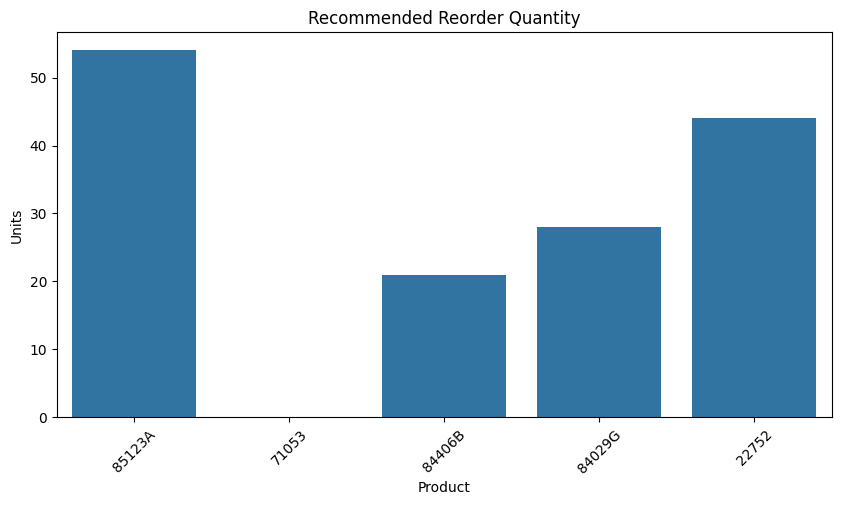

In [12]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=inventory,

    x="StockCode",

    y="RecommendedOrder"

)

plt.title("Recommended Reorder Quantity")

plt.xlabel("Product")

plt.ylabel("Units")

plt.xticks(rotation=45)

plt.show()